<a href="https://colab.research.google.com/github/MrArpan09/Worst-Group-Optimization/blob/main/project18_worst_group_optimisation_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Worst-Group Optimisation for Face Attribute Classification

---

| | |
|---|---|
| **Course** | Machine Learning — Summer 2026 |
| **Project** | Project 18 Worst-Group Optimisation for Face Attribute Classification|
| **Group** | ML_SE_ALL_18 |
| **Members** | Member 1 — Ashwin Shrestha — 82459101 |
| | Member 2 — Arpan Rai — 94985626  |
| | Member 3 — Om Savani — 99214646 |

---


## 1. Problem Statement

**What question is this project trying to answer?**
> Can we train a face attribute classifier that performs well not just on average, but specifically on the hardest demographic subgroup?

**The core problem:**
- Standard machine learning models minimise **average loss** across all training samples
- This causes models to fail on **minority subgroups** whose samples are underrepresented
- A model can achieve high average accuracy while being completely useless for a minority group

**Concrete example in this project:**
- Task: classify whether a person has **blond hair** (binary: blond / non-blond)
- Dataset: CelebA — 94% of blond individuals are **female**
- The model learns a shortcut: **blond → female**
- Result: 93.91% average accuracy, but only **21.11% accuracy on blond males**

**What this project compares:**
- **ERM** — Empirical Risk Minimisation (standard baseline)
- **Reweighting** — inverse-frequency group reweighting
- **GroupDRO** — Group Distributionally Robust Optimisation

**Primary metric:**
- **Worst-group accuracy** — minimum accuracy across all demographic subgroups
- Average accuracy alone is insufficient and misleading

**Why this matters:**
- Biased classifiers affect real-world systems: hiring tools, healthcare diagnosis, facial recognition
- A model that fails on a minority group causes systematic, not random, harm


## 2. Dataset

**Dataset:** CelebFaces Attributes Dataset (CelebA)
**Source:** https://mmlab.ie.cuhk.edu.hk/projects/CelebA.html

**Key facts:**
- 202,599 celebrity face images
- 40 binary attribute annotations per image
- 10,177 unique identities
- Images are aligned and cropped to 218×178 pixels

**Files used:**
- `img_align_celeba.zip` — aligned and cropped face images (1.34 GB)
- `list_attr_celeba.txt` — 40 binary attribute labels per image
- `list_eval_partition.txt` — official train/val/test split

**Target and spurious attribute:**
- **Target label y**: Attribute 9 — Blond_Hair (0 = non-blond, 1 = blond)
- **Spurious attribute a**: Attribute 20 — Male (0 = female, 1 = male)

**Group definition:** g = 2y + a → 4 subgroups

| Group | Label | Gender | Train Count | Train % |
|---|---|---|---|---|
| G0 | Non-blond | Female | 71,629 | 44.0% |
| G1 | Non-blond | Male | 66,874 | 41.1% |
| G2 | Blond | Female | 22,880 | 14.1% |
| **G3** | **Blond** | **Male** | **1,387** | **0.9%** |

**Official data split:**
- Train: 162,770 images
- Validation: 19,867 images
- Test: 19,962 images

**Key imbalance:** G3 (Blond Male) is 51× smaller than G0 (Non-blond Female)


### 2.1 Setup & Data Loading

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, random, time, csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.datasets import CelebA

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

# ── Data setup from Google Drive ──────────────────────────────────────────
src = '/content/drive/MyDrive/Colab Notebooks/CelebA'
os.makedirs('/content/celeba/celeba', exist_ok=True)

os.system(f'cp "{src}/list_attr_celeba.txt" /content/celeba/celeba/')
os.system(f'cp "{src}/list_eval_partition.txt" /content/celeba/celeba/')
print('Annotation files copied.')

print('Unzipping images... (3-5 mins)')
os.system(f'unzip -q -o "{src}/img_align_celeba.zip" -d /content/celeba/celeba/')
print('Unzip complete.')

# Create required stub files for torchvision integrity bypass
img_dir  = '/content/celeba/celeba/img_align_celeba'
n_images = len(os.listdir(img_dir))
print(f'Images found: {n_images:,}')

with open('/content/celeba/celeba/identity_CelebA.txt', 'w') as f:
    for i in range(1, n_images + 1):
        f.write(f'{i:06d}.jpg 1\n')

with open('/content/celeba/celeba/list_bbox_celeba.txt', 'w') as f:
    f.write(f'{n_images}\n')
    f.write('image_id x_1 y_1 width height\n')
    for i in range(1, n_images + 1):
        f.write(f'{i:06d}.jpg 1 1 1 1\n')

with open('/content/celeba/celeba/list_landmarks_align_celeba.txt', 'w') as f:
    f.write(f'{n_images}\n')
    f.write('lefteye_x lefteye_y righteye_x righteye_y nose_x nose_y leftmouth_x leftmouth_y rightmouth_x rightmouth_y\n')
    for i in range(1, n_images + 1):
        f.write(f'{i:06d}.jpg 1 1 1 1 1 1 1 1 1 1\n')

CelebA._check_integrity = lambda self: True
print('Setup complete.')


Mounted at /content/drive
Using device: cuda
Annotation files copied.
Unzipping images... (3-5 mins)
Unzip complete.
Images found: 202,599
Setup complete.


### 2.2 Group-Aware Dataset

In [ ]:
BLOND_IDX  = 9
MALE_IDX   = 20
GROUP_NAMES = ['Non-blond Female', 'Non-blond Male', 'Blond Female', 'Blond Male']

class CelebAGroupDataset(Dataset):
    """
    Wraps CelebA and exposes (image, label, group_id).
    group_id = 2*y + a  where y=blond label, a=male attribute
    """
    def __init__(self, root, split, transform=None):
        self.celeba = CelebA(root=root, split=split, target_type='attr',
                             transform=transform, download=False)
        attrs      = self.celeba.attr
        self.y     = attrs[:, BLOND_IDX].long()   # target: blond hair
        self.a     = attrs[:, MALE_IDX].long()    # spurious: gender
        self.group = 2 * self.y + self.a          # group id in {0,1,2,3}
        self.n_groups = 4

    def __len__(self):
        return len(self.celeba)

    def __getitem__(self, idx):
        img, _ = self.celeba[idx]
        return img, self.y[idx], self.group[idx]

# Image transforms
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

DATA_ROOT = '/content/celeba'
os.makedirs(DATA_ROOT, exist_ok=True)

print('Loading CelebA...')
train_dataset = CelebAGroupDataset(DATA_ROOT, 'train', transform=train_transform)
val_dataset   = CelebAGroupDataset(DATA_ROOT, 'valid', transform=eval_transform)
test_dataset  = CelebAGroupDataset(DATA_ROOT, 'test',  transform=eval_transform)
print(f'Train: {len(train_dataset):,} | Val: {len(val_dataset):,} | Test: {len(test_dataset):,}')


Loading CelebA...
Train: 162,770 | Val: 19,867 | Test: 19,962


### 2.3 Exploratory Data Analysis


Train (162,770 samples):
  G0 Non-blond Female      : 71,629  (44.0%)
  G1 Non-blond Male        : 66,874  (41.1%)
  G2 Blond Female          : 22,880  (14.1%)
  G3 Blond Male            :  1,387  (0.9%)

Validation (19,867 samples):
  G0 Non-blond Female      :  8,535  (43.0%)
  G1 Non-blond Male        :  8,276  (41.7%)
  G2 Blond Female          :  2,874  (14.5%)
  G3 Blond Male            :    182  (0.9%)

Test (19,962 samples):
  G0 Non-blond Female      :  9,767  (48.9%)
  G1 Non-blond Male        :  7,535  (37.7%)
  G2 Blond Female          :  2,480  (12.4%)
  G3 Blond Male            :    180  (0.9%)


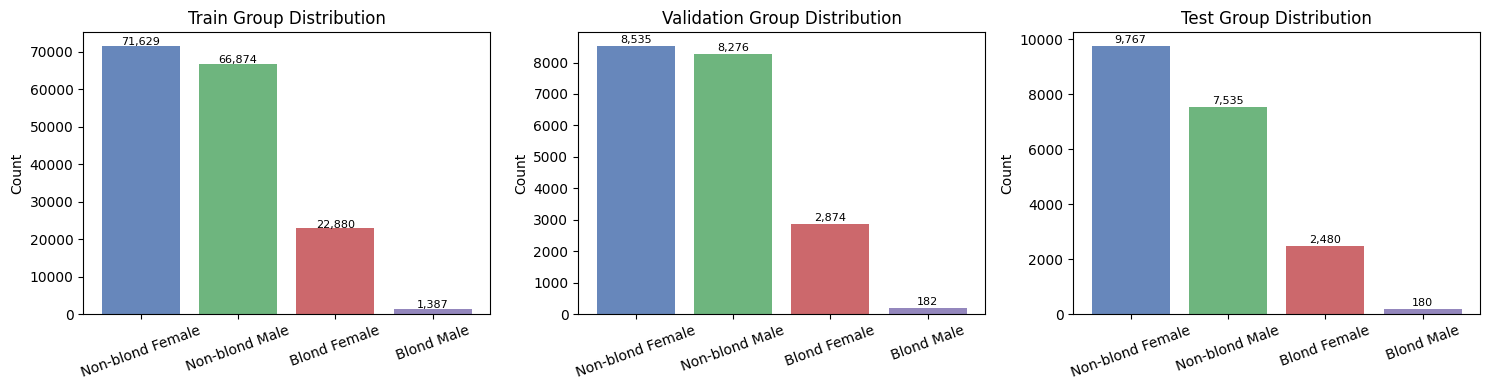


Key observation: G3 (Blond Male) has only 1,387 training samples — 51x fewer than G0.


In [ ]:
# ── Group distribution across splits ─────────────────────────────────────
def group_counts(dataset, name=''):
    counts = torch.bincount(dataset.group, minlength=4)
    total  = len(dataset)
    print(f'\n{name} ({total:,} samples):')
    for g, (n, gname) in enumerate(zip(counts, GROUP_NAMES)):
        print(f'  G{g} {gname:<22}: {n:>6,}  ({100*n/total:.1f}%)')
    return counts

train_counts = group_counts(train_dataset, 'Train')
val_counts   = group_counts(val_dataset,   'Validation')
test_counts  = group_counts(test_dataset,  'Test')

# Plot group distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ['#4C72B0','#55A868','#C44E52','#8172B2']
for ax, counts, title in zip(axes,
                              [train_counts, val_counts, test_counts],
                              ['Train', 'Validation', 'Test']):
    bars = ax.bar(GROUP_NAMES, counts.numpy(), color=colors, alpha=0.85)
    ax.set_title(f'{title} Group Distribution')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=20)
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                f'{count:,}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('group_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print('\nKey observation: G3 (Blond Male) has only 1,387 training samples — 51x fewer than G0.')


### 2.4 Sample Images from Each Group

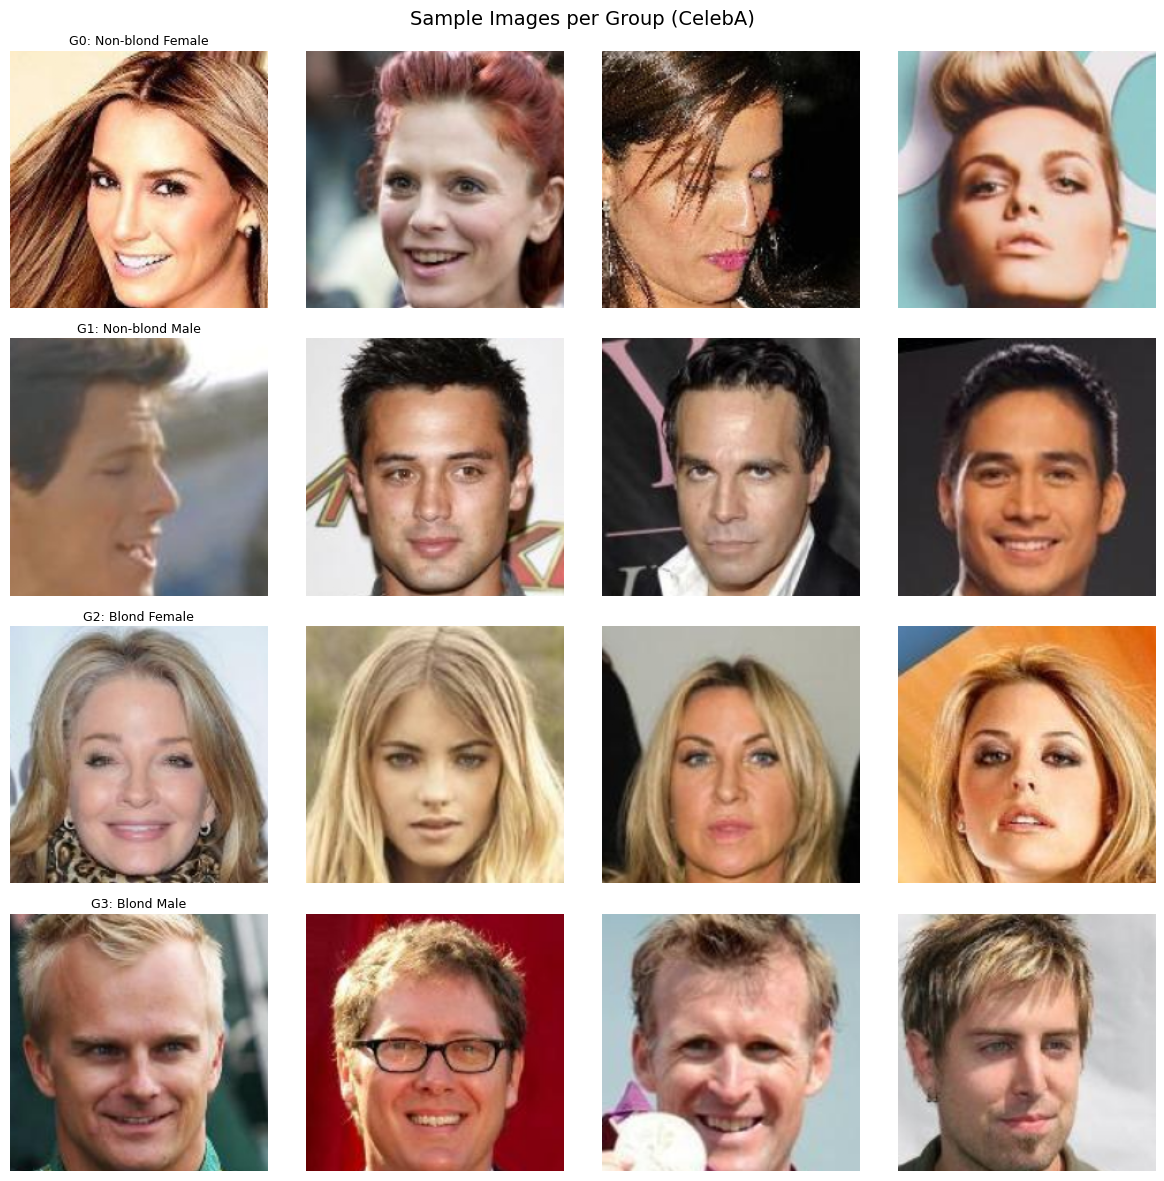

Each row shows 4 sample images from one subgroup.


In [ ]:
# Show sample images from each group
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
fig.suptitle('Sample Images per Group (CelebA)', fontsize=14)

# Use eval_transform without normalization for display
display_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
])

display_dataset = CelebAGroupDataset(DATA_ROOT, 'train', transform=display_transform)

shown = {0: 0, 1: 0, 2: 0, 3: 0}
needed = 4

idx = 0
while any(v < needed for v in shown.values()) and idx < len(display_dataset):
    img, label, group = display_dataset[idx]
    g = group.item()
    if shown[g] < needed:
        col = shown[g]
        ax  = axes[g][col]
        ax.imshow(img.permute(1, 2, 0).numpy())
        ax.axis('off')
        if col == 0:
            ax.set_title(f'G{g}: {GROUP_NAMES[g]}', fontsize=9, pad=4)
        shown[g] += 1
    idx += 1

plt.tight_layout()
plt.savefig('sample_images.png', dpi=100, bbox_inches='tight')
plt.show()
print('Each row shows 4 sample images from one subgroup.')


## 3. Methodology

**Full workflow:**
1. **Data preparation** — load CelebA, define 4 subgroups using label × gender
2. **Preprocessing** — random crop + flip for training; resize + centre crop for eval; ImageNet normalisation
3. **Model design** — pretrained ResNet-18, freeze backbone, replace final FC layer
4. **Training** — three separate methods: ERM, Reweighting, GroupDRO
5. **Validation** — monitor worst-group accuracy after each epoch
6. **Evaluation** — report average, worst-group, and per-group accuracy on test set
7. **Error analysis** — inspect failure cases on worst group

**Preprocessing choices:**
- RandomResizedCrop(224) — data augmentation to improve generalisation
- RandomHorizontalFlip() — faces are symmetric, augmentation is valid
- ImageNet normalisation — required because we use ImageNet pretrained weights

**Split design:**
- Used the **official CelebA split** (list_eval_partition.txt)
- No random splitting — official split ensures no identity leakage across train/val/test

**Baseline:** ERM (Empirical Risk Minimisation) — standard training with no group awareness


## 4. Selected Models

**Architecture:** ResNet-18 (Residual Network, 18 layers)

**Why ResNet-18?**
- Pretrained on ImageNet (1.2M images, 1000 classes) — strong visual features already learned
- Transfer learning: reuse backbone features, only train final layer
- Computationally feasible on Colab T4 GPU
- Standard benchmark model for CelebA in the fairness literature

**Transfer learning approach:**
- Freeze all 11M backbone parameters (requires_grad = False)
- Replace final FC layer: 512 → 2 (blond / non-blond)
- Only 1,026 parameters trained
- Avoids overfitting on small minority group

**Training configuration:**
- Optimiser: Adam (lr = 0.001, step decay ×0.5 every 2 epochs)
- Batch size: 128
- Epochs: 5
- Loss: CrossEntropyLoss (with per-method modifications)


In [ ]:
def build_model():
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    for param in model.parameters():
        param.requires_grad = False      # freeze backbone — no gradient updates
    model.fc = nn.Linear(model.fc.in_features, 2)   # replace final layer
    return model.to(DEVICE)

model_erm = build_model()
model_rw  = build_model()
model_dro = build_model()

total     = sum(p.numel() for p in model_erm.parameters())
trainable = sum(p.numel() for p in model_erm.parameters() if p.requires_grad)
print(f'Total parameters    : {total:,}')
print(f'Trainable parameters: {trainable:,}  (final FC layer only)')
print(f'Frozen parameters   : {total - trainable:,}  (ResNet-18 backbone)')


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 226MB/s]


Total parameters    : 11,177,538
Trainable parameters: 1,026  (final FC layer only)
Frozen parameters   : 11,176,512  (ResNet-18 backbone)


## 5. Evaluation Criterion

**Why not just average accuracy?**
- Average accuracy aggregates over all samples equally
- Majority groups dominate — a model can score 93% average while completely failing the minority
- Average accuracy hides systematic discrimination

**Metrics used:**

| Metric | Definition | Why used |
|---|---|---|
| Average Accuracy | % correct across all test samples | Standard baseline metric |
| Worst-Group Accuracy | min accuracy across 4 subgroups | Primary fairness metric |
| Per-Group Accuracy | accuracy for each of G0–G3 | Full picture of group-level performance |

**Worst-group accuracy formally:**
$$\text{Worst-Group Acc} = \min_{g \in \{G0, G1, G2, G3\}} \text{Acc}_g$$

**Why worst-group accuracy is the right metric for this project:**
- Directly measures the problem we are solving
- A model that achieves 21% on blond males has failed regardless of its average
- Matches the GroupDRO objective — minimise maximum group loss


In [ ]:
def evaluate(model, loader, n_groups=4):
    """
    Returns avg_acc, worst_group_acc, per_group_accs, per_group_losses
    """
    model.eval()
    criterion = nn.CrossEntropyLoss(reduction='none')
    all_preds, all_labels, all_groups, all_losses = [], [], [], []

    with torch.no_grad():
        for imgs, labels, groups in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            logits = model(imgs)
            loss   = criterion(logits, labels)
            preds  = logits.argmax(dim=1)
            all_preds.append(preds.cpu());  all_labels.append(labels.cpu())
            all_groups.append(groups);      all_losses.append(loss.cpu())

    preds  = torch.cat(all_preds);  labels = torch.cat(all_labels)
    groups = torch.cat(all_groups); losses = torch.cat(all_losses)

    avg_acc = (preds == labels).float().mean().item()
    group_accs, group_losses = [], []
    for g in range(n_groups):
        mask = (groups == g)
        if mask.sum() == 0:
            group_accs.append(float('nan')); group_losses.append(float('nan'))
        else:
            group_accs.append((preds[mask] == labels[mask]).float().mean().item())
            group_losses.append(losses[mask].mean().item())

    worst_acc = min(a for a in group_accs if not np.isnan(a))
    return avg_acc, worst_acc, group_accs, group_losses


def print_results(tag, avg_acc, worst_acc, group_accs):
    print(f'\n── {tag} ──')
    print(f'  Average Accuracy   : {avg_acc*100:.2f}%')
    print(f'  Worst-Group Acc    : {worst_acc*100:.2f}%')
    for g, (acc, name) in enumerate(zip(group_accs, GROUP_NAMES)):
        marker = ' ← WORST' if not np.isnan(acc) and acc == min(
            a for a in group_accs if not np.isnan(a)) else ''
        print(f'  G{g} {name:<22}: {acc*100:.2f}%{marker}')


### DataLoaders & Group Weights

In [ ]:
BATCH_SIZE  = 128
NUM_WORKERS = 2

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

# Inverse-frequency group weights for Reweighting method
n_groups           = train_dataset.n_groups
group_counts_train = torch.bincount(train_dataset.group, minlength=n_groups).float()
group_weights      = (len(train_dataset) / n_groups) / group_counts_train
group_weights      = group_weights / group_weights.sum() * n_groups

print('Group inverse-frequency weights:')
for g, (w, name) in enumerate(zip(group_weights, GROUP_NAMES)):
    print(f'  G{g} {name:<22}: {w:.4f}')
print(f'\nBlond Male weight is {group_weights[3]/group_weights[0]:.1f}x higher than Non-blond Female')


Group inverse-frequency weights:
  G0 Non-blond Female      : 0.0704
  G1 Non-blond Male        : 0.0754
  G2 Blond Female          : 0.2203
  G3 Blond Male            : 3.6340

Blond Male weight is 51.6x higher than Non-blond Female


## 6. Training Methods

### Shared training loop
All three methods use the same training loop structure with a pluggable loss function.


In [ ]:
EPOCHS = 5
LR     = 1e-3

def train_epoch(model, loader, optimizer, loss_fn):
    model.train()
    running = 0.0
    for step, (imgs, labels, groups) in enumerate(loader):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        loss = loss_fn(model, imgs, labels, groups)
        loss.backward()
        optimizer.step()
        running += loss.item()
        if (step + 1) % 300 == 0:
            print(f'    step {step+1}/{len(loader)} | loss {running/(step+1):.4f}')
    return running / len(loader)


### Method 1: ERM (Baseline)

**Definition:** Minimise the mean cross-entropy loss across all samples equally.

$$\hat{\theta}_{ERM} = \arg\min_\theta \frac{1}{N}\sum_{i=1}^N \mathcal{L}(f_\theta(x_i), y_i)$$

**Why it fails:** Majority groups (G0: 71,629 samples) dominate the gradient signal. The model learns the spurious correlation blond → female and ignores blond males (G3: 1,387 samples).


In [ ]:
def erm_loss(model, imgs, labels, groups):
    return nn.CrossEntropyLoss()(model(imgs), labels)

optimizer_erm = optim.Adam(model_erm.fc.parameters(), lr=LR)
scheduler_erm = optim.lr_scheduler.StepLR(optimizer_erm, step_size=2, gamma=0.5)
erm_history   = {'train_loss': [], 'val_avg': [], 'val_worst': []}

print('=== Training ERM (Baseline) ===')
for epoch in range(1, EPOCHS + 1):
    t0      = time.time()
    tr_loss = train_epoch(model_erm, train_loader, optimizer_erm, erm_loss)
    scheduler_erm.step()
    va, vw, vg, _ = evaluate(model_erm, val_loader)
    erm_history['train_loss'].append(tr_loss)
    erm_history['val_avg'].append(va)
    erm_history['val_worst'].append(vw)
    print(f'Epoch {epoch}/{EPOCHS} | loss {tr_loss:.4f} | val avg {va*100:.2f}% | val worst {vw*100:.2f}% | {time.time()-t0:.0f}s')

erm_test_avg, erm_test_worst, erm_test_g_accs, _ = evaluate(model_erm, test_loader)
print_results('ERM — Test', erm_test_avg, erm_test_worst, erm_test_g_accs)


=== Training ERM (Baseline) ===
    step 300/1272 | loss 0.1967
    step 600/1272 | loss 0.1946
    step 900/1272 | loss 0.1950
    step 1200/1272 | loss 0.1941
Epoch 1/5 | loss 0.1938 | val avg 93.34% | val worst 12.64% | 240s
    step 300/1272 | loss 0.1888
    step 600/1272 | loss 0.1919
    step 900/1272 | loss 0.1918
    step 1200/1272 | loss 0.1920
Epoch 2/5 | loss 0.1921 | val avg 93.50% | val worst 14.29% | 240s
    step 300/1272 | loss 0.1944
    step 600/1272 | loss 0.1919
    step 900/1272 | loss 0.1914
    step 1200/1272 | loss 0.1906
Epoch 3/5 | loss 0.1908 | val avg 93.42% | val worst 14.84% | 239s
    step 300/1272 | loss 0.1906
    step 600/1272 | loss 0.1901
    step 900/1272 | loss 0.1910
    step 1200/1272 | loss 0.1898
Epoch 4/5 | loss 0.1897 | val avg 93.29% | val worst 26.37% | 242s
    step 300/1272 | loss 0.1873
    step 600/1272 | loss 0.1880
    step 900/1272 | loss 0.1901
    step 1200/1272 | loss 0.1887
Epoch 5/5 | loss 0.1887 | val avg 93.53% | val worst 18

### Method 2: Reweighting

**Definition:** Assign each sample a weight inversely proportional to its group size.

$$w_g = \frac{N / |\mathcal{G}|}{n_g}, \quad \mathcal{L}_{RW} = \frac{\sum_i w_{g(i)} \cdot \ell_i}{\sum_i w_{g(i)}}$$

**Why it helps:** Blond males (G3) get weight 3.634 vs 0.070 for non-blond females — 51× more influence on the loss.

**Limitation:** Weights are fixed throughout training — they do not adapt to how the model is actually performing.


In [ ]:
gw = group_weights.to(DEVICE)

def rw_loss(model, imgs, labels, groups):
    logits          = model(imgs)
    per_sample_loss = nn.CrossEntropyLoss(reduction='none')(logits, labels)
    sample_weights  = gw[groups.to(DEVICE)]
    return (sample_weights * per_sample_loss).sum() / sample_weights.sum()

optimizer_rw = optim.Adam(model_rw.fc.parameters(), lr=LR)
scheduler_rw = optim.lr_scheduler.StepLR(optimizer_rw, step_size=2, gamma=0.5)
rw_history   = {'train_loss': [], 'val_avg': [], 'val_worst': []}

print('=== Training Reweighting ===')
for epoch in range(1, EPOCHS + 1):
    t0      = time.time()
    tr_loss = train_epoch(model_rw, train_loader, optimizer_rw, rw_loss)
    scheduler_rw.step()
    va, vw, vg, _ = evaluate(model_rw, val_loader)
    rw_history['train_loss'].append(tr_loss)
    rw_history['val_avg'].append(va)
    rw_history['val_worst'].append(vw)
    print(f'Epoch {epoch}/{EPOCHS} | loss {tr_loss:.4f} | val avg {va*100:.2f}% | val worst {vw*100:.2f}% | {time.time()-t0:.0f}s')

rw_test_avg, rw_test_worst, rw_test_g_accs, _ = evaluate(model_rw, test_loader)
print_results('Reweighting — Test', rw_test_avg, rw_test_worst, rw_test_g_accs)


=== Training Reweighting ===
    step 300/1272 | loss 0.3488
    step 600/1272 | loss 0.3658
    step 900/1272 | loss 0.3665
    step 1200/1272 | loss 0.3666
Epoch 1/5 | loss 0.3665 | val avg 86.20% | val worst 80.34% | 239s
    step 300/1272 | loss 0.3793
    step 600/1272 | loss 0.3773
    step 900/1272 | loss 0.3752
    step 1200/1272 | loss 0.3735
Epoch 2/5 | loss 0.3732 | val avg 83.69% | val worst 76.74% | 239s
    step 300/1272 | loss 0.3581
    step 600/1272 | loss 0.3549
    step 900/1272 | loss 0.3526
    step 1200/1272 | loss 0.3542
Epoch 3/5 | loss 0.3545 | val avg 82.12% | val worst 75.42% | 241s
    step 300/1272 | loss 0.3613
    step 600/1272 | loss 0.3628
    step 900/1272 | loss 0.3603
    step 1200/1272 | loss 0.3608
Epoch 4/5 | loss 0.3599 | val avg 87.88% | val worst 81.32% | 239s
    step 300/1272 | loss 0.3521
    step 600/1272 | loss 0.3523
    step 900/1272 | loss 0.3497
    step 1200/1272 | loss 0.3491
Epoch 5/5 | loss 0.3487 | val avg 84.86% | val worst 78.73

### Method 3: GroupDRO

**Definition:** Minimise the maximum group loss via adaptive group weights (Sagawa et al., NeurIPS 2020).

$$\hat{\theta}_{DRO} = \arg\min_\theta \max_{g} \mathbb{E}_{(x,y) \sim \hat{P}_g}[\mathcal{L}(f_\theta(x), y)]$$

**Group weight update (every training step):**
$$q_g \leftarrow q_g \cdot \exp(\eta_q \cdot \hat{L}_g(\theta)), \quad \text{then normalise to sum to 1}$$

**Why it beats Reweighting:** Weights adapt dynamically — if blond males start failing mid-training, their weight increases immediately in the next step.

**Hyperparameter:** η_q = 0.01 (from original paper — controls aggressiveness of weight updates)


In [ ]:
DRO_ETA_Q = 0.01
q = torch.ones(n_groups, device=DEVICE) / n_groups   # uniform initialisation

def dro_loss(model, imgs, labels, groups):
    global q
    logits          = model(imgs)
    per_sample_loss = nn.CrossEntropyLoss(reduction='none')(logits, labels)
    group_losses    = torch.zeros(n_groups, device=DEVICE)
    for g in range(n_groups):
        mask = (groups.to(DEVICE) == g)
        if mask.sum() > 0:
            group_losses[g] = per_sample_loss[mask].mean()
    with torch.no_grad():
        q *= torch.exp(DRO_ETA_Q * group_losses.detach())
        q /= q.sum()   # project onto probability simplex
    return (q.detach() * group_losses).sum()

optimizer_dro = optim.Adam(model_dro.fc.parameters(), lr=LR)
scheduler_dro = optim.lr_scheduler.StepLR(optimizer_dro, step_size=2, gamma=0.5)
dro_history   = {'train_loss': [], 'val_avg': [], 'val_worst': [], 'q_history': []}

print('=== Training GroupDRO ===')
for epoch in range(1, EPOCHS + 1):
    t0      = time.time()
    tr_loss = train_epoch(model_dro, train_loader, optimizer_dro, dro_loss)
    scheduler_dro.step()
    va, vw, vg, _ = evaluate(model_dro, val_loader)
    dro_history['train_loss'].append(tr_loss)
    dro_history['val_avg'].append(va)
    dro_history['val_worst'].append(vw)
    dro_history['q_history'].append(q.cpu().tolist())
    print(f'Epoch {epoch}/{EPOCHS} | loss {tr_loss:.4f} | val avg {va*100:.2f}% | val worst {vw*100:.2f}% | '
          f'q={[f"{v:.3f}" for v in q.tolist()]} | {time.time()-t0:.0f}s')

dro_test_avg, dro_test_worst, dro_test_g_accs, _ = evaluate(model_dro, test_loader)
print_results('GroupDRO — Test', dro_test_avg, dro_test_worst, dro_test_g_accs)


=== Training GroupDRO ===
    step 300/1272 | loss 0.3280
    step 600/1272 | loss 0.3180
    step 900/1272 | loss 0.3249
    step 1200/1272 | loss 0.3278
Epoch 1/5 | loss 0.3279 | val avg 84.04% | val worst 80.22% | q=['0.307', '0.198', '0.220', '0.276'] | 240s
    step 300/1272 | loss 0.3403
    step 600/1272 | loss 0.3269
    step 900/1272 | loss 0.3369
    step 1200/1272 | loss 0.3374
Epoch 2/5 | loss 0.3374 | val avg 88.28% | val worst 81.87% | q=['0.291', '0.209', '0.207', '0.293'] | 242s
    step 300/1272 | loss 0.3100
    step 600/1272 | loss 0.3287
    step 900/1272 | loss 0.3309
    step 1200/1272 | loss 0.3281
Epoch 3/5 | loss 0.3260 | val avg 89.23% | val worst 78.02% | q=['0.292', '0.218', '0.204', '0.287'] | 241s
    step 300/1272 | loss 0.3292
    step 600/1272 | loss 0.3298
    step 900/1272 | loss 0.3270
    step 1200/1272 | loss 0.3221
Epoch 4/5 | loss 0.3232 | val avg 86.25% | val worst 82.39% | q=['0.304', '0.200', '0.210', '0.287'] | 240s
    step 300/1272 | loss 0

## 7. Results

In [ ]:
methods    = ['ERM', 'Reweighting', 'GroupDRO']
avg_accs   = [erm_test_avg,   rw_test_avg,   dro_test_avg]
worst_accs = [erm_test_worst, rw_test_worst, dro_test_worst]
all_g_accs = [erm_test_g_accs, rw_test_g_accs, dro_test_g_accs]

print('\n' + '='*70)
print(f'  {"Metric":<30}' + ''.join(f'{m:>13}' for m in methods))
print('='*70)
print(f'  {"Average Accuracy":<30}' + ''.join(f'{a*100:>12.2f}%' for a in avg_accs))
print(f'  {"Worst-Group Accuracy":<30}' + ''.join(f'{a*100:>12.2f}%' for a in worst_accs))
print('-'*70)
for g, name in enumerate(GROUP_NAMES):
    row = f'  G{g} {name:<26}'
    for g_accs in all_g_accs:
        row += f'{g_accs[g]*100:>12.2f}%'
    print(row)
print('='*70)

print(f'\nWorst-group improvement: ERM {erm_test_worst*100:.2f}% → GroupDRO {dro_test_worst*100:.2f}% (+{(dro_test_worst-erm_test_worst)*100:.2f}pp)')
print(f'Average accuracy cost  : ERM {erm_test_avg*100:.2f}% → GroupDRO {dro_test_avg*100:.2f}% ({(dro_test_avg-erm_test_avg)*100:.2f}pp)')



  Metric                                  ERM  Reweighting     GroupDRO
  Average Accuracy                     94.01%       85.92%       88.19%
  Worst-Group Accuracy                 21.11%       80.56%       78.33%
----------------------------------------------------------------------
  G0 Non-blond Female                 95.48%       82.85%       86.35%
  G1 Non-blond Male                   99.69%       86.90%       89.10%
  G2 Blond Female                     76.21%       95.40%       93.35%
  G3 Blond Male                       21.11%       80.56%       78.33%

Worst-group improvement: ERM 21.11% → GroupDRO 78.33% (+57.22pp)
Average accuracy cost  : ERM 94.01% → GroupDRO 88.19% (-5.82pp)


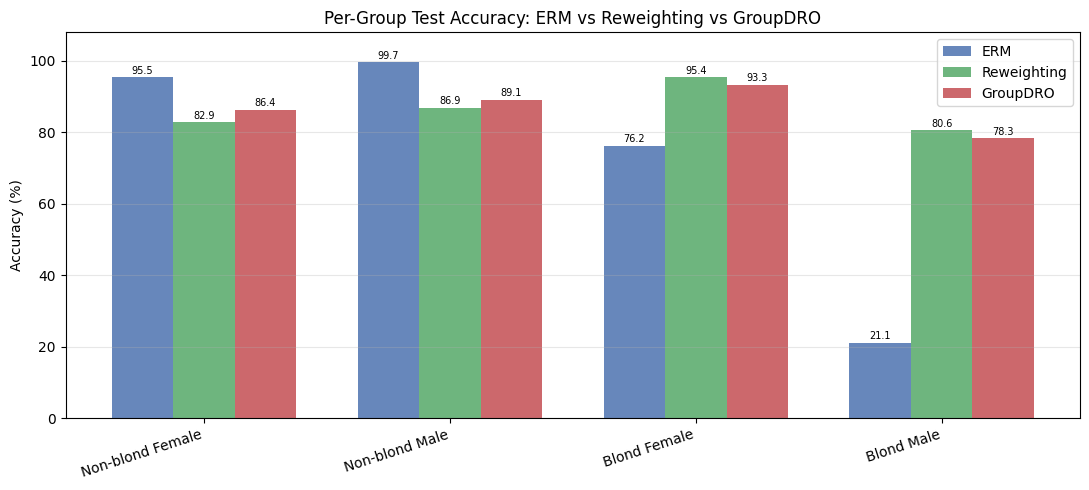

In [ ]:
# Plot 1: Per-group accuracy bar chart
x     = np.arange(len(GROUP_NAMES))
width = 0.25
colors_method = ['#4C72B0', '#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(11, 5))
for i, (method, g_accs, col) in enumerate(zip(methods, all_g_accs, colors_method)):
    bars = ax.bar(x + (i-1)*width, [a*100 for a in g_accs],
                  width, label=method, color=col, alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(GROUP_NAMES, rotation=18, ha='right')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Per-Group Test Accuracy: ERM vs Reweighting vs GroupDRO')
ax.legend(); ax.set_ylim(0, 108); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('per_group_accuracy.png', dpi=120, bbox_inches='tight')
plt.show()


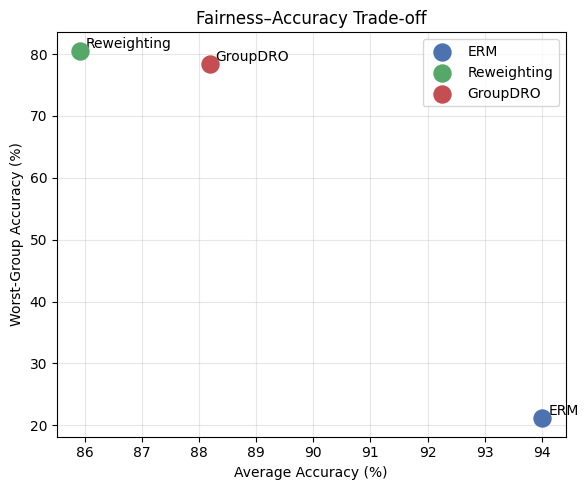

Top-right = ideal: high average AND high worst-group accuracy.


In [ ]:
# Plot 2: Fairness-Accuracy trade-off scatter
fig, ax = plt.subplots(figsize=(6, 5))
for method, avg, worst, col in zip(methods, avg_accs, worst_accs, colors_method):
    ax.scatter(avg*100, worst*100, s=150, color=col, zorder=5, label=method)
    ax.annotate(method, (avg*100 + 0.1, worst*100 + 0.5), fontsize=10)
ax.set_xlabel('Average Accuracy (%)')
ax.set_ylabel('Worst-Group Accuracy (%)')
ax.set_title('Fairness–Accuracy Trade-off')
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout()
plt.savefig('tradeoff_scatter.png', dpi=120, bbox_inches='tight')
plt.show()
print('Top-right = ideal: high average AND high worst-group accuracy.')


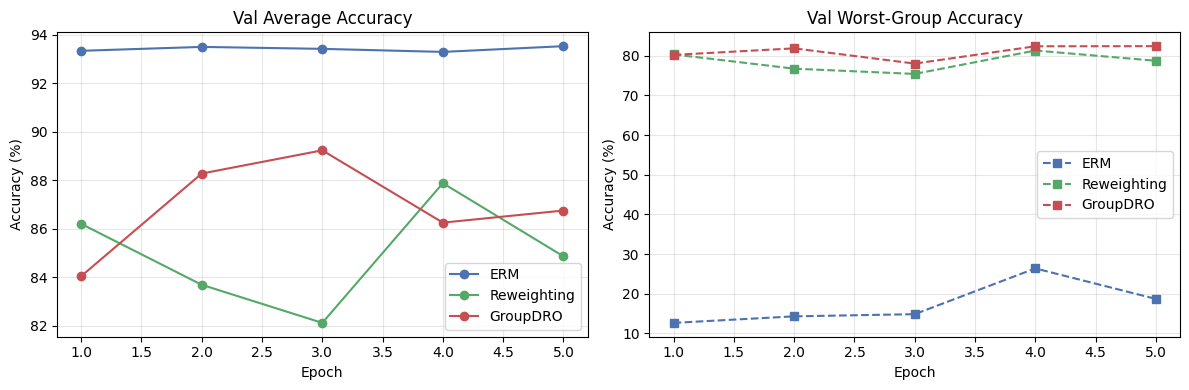

In [ ]:
# Plot 3: Validation curves
ep = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for method, hist, col in zip(methods, [erm_history, rw_history, dro_history], colors_method):
    axes[0].plot(ep, [a*100 for a in hist['val_avg']],   'o-', label=method, color=col)
    axes[1].plot(ep, [a*100 for a in hist['val_worst']], 's--', label=method, color=col)
for ax, title in zip(axes, ['Val Average Accuracy', 'Val Worst-Group Accuracy']):
    ax.set_title(title); ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy (%)'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=120, bbox_inches='tight')
plt.show()


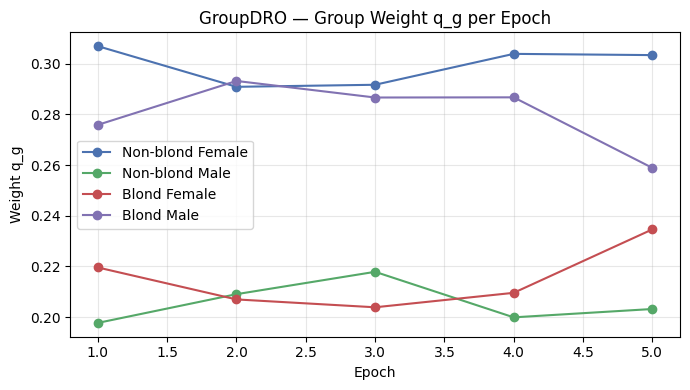

In [ ]:
# Plot 4: DRO weight evolution
q_hist = np.array(dro_history['q_history'])
colors_group = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']
fig, ax = plt.subplots(figsize=(7, 4))
for g, (name, col) in enumerate(zip(GROUP_NAMES, colors_group)):
    ax.plot(ep, q_hist[:, g], 'o-', label=name, color=col)
ax.set_title('GroupDRO — Group Weight q_g per Epoch')
ax.set_xlabel('Epoch'); ax.set_ylabel('Weight q_g')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('dro_weights.png', dpi=120, bbox_inches='tight')
plt.show()


## 8. Error Analysis & Limitations

### 8.1 Where ERM Fails — Failure Case Analysis


/tmp/ipykernel_7474/3983076011.py:49: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7474/3983076011.py:50: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('error_analysis.png', dpi=100, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


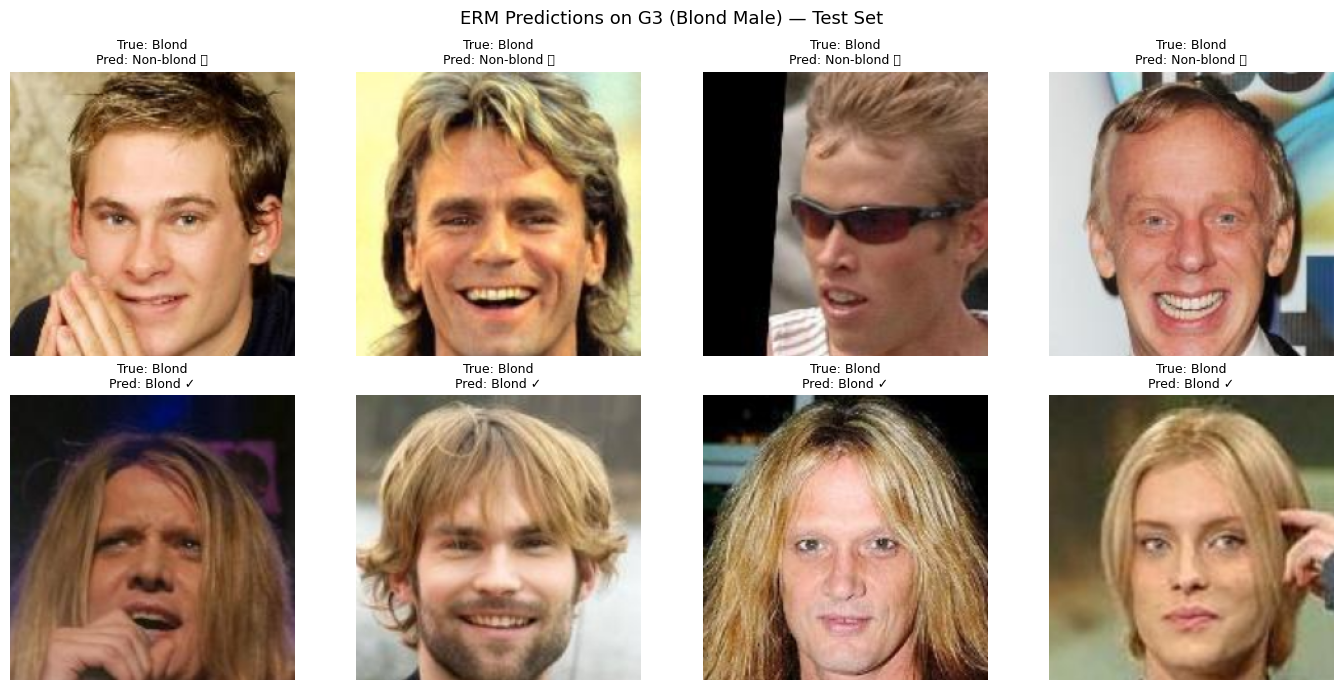

Top row: blond males that ERM misclassifies as non-blond
Bottom row: blond males that ERM correctly classifies


In [ ]:
# Show images that ERM gets wrong in G3 (Blond Male)
model_erm.eval()

display_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
])

display_dataset = CelebAGroupDataset(DATA_ROOT, 'test', transform=display_transform)

wrong_blond_male = []
correct_blond_male = []

with torch.no_grad():
    for idx in range(len(display_dataset)):
        img, label, group = display_dataset[idx]
        if group.item() != 3:   # only look at blond males (G3)
            continue
        # Run through ERM model using eval_transform version
        img_tensor = eval_transform(transforms.ToPILImage()(img)).unsqueeze(0).to(DEVICE)
        logit = model_erm(img_tensor)
        pred  = logit.argmax(dim=1).item()
        if pred != label.item() and len(wrong_blond_male) < 4:
            wrong_blond_male.append((img, label.item(), pred))
        elif pred == label.item() and len(correct_blond_male) < 4:
            correct_blond_male.append((img, label.item(), pred))
        if len(wrong_blond_male) >= 4 and len(correct_blond_male) >= 4:
            break

label_names = ['Non-blond', 'Blond']

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('ERM Predictions on G3 (Blond Male) — Test Set', fontsize=13)

for col, (img, true, pred) in enumerate(wrong_blond_male):
    axes[0][col].imshow(img.permute(1,2,0).numpy())
    axes[0][col].set_title(f'True: {label_names[true]}\nPred: {label_names[pred]} ❌', fontsize=9)
    axes[0][col].axis('off')

for col, (img, true, pred) in enumerate(correct_blond_male):
    axes[1][col].imshow(img.permute(1,2,0).numpy())
    axes[1][col].set_title(f'True: {label_names[true]}\nPred: {label_names[pred]} ✓', fontsize=9)
    axes[1][col].axis('off')

axes[0][0].set_ylabel('ERM Wrong', fontsize=10)
axes[1][0].set_ylabel('ERM Correct', fontsize=10)

plt.tight_layout()
plt.savefig('error_analysis.png', dpi=100, bbox_inches='tight')
plt.show()
print('Top row: blond males that ERM misclassifies as non-blond')
print('Bottom row: blond males that ERM correctly classifies')


### 8.2 Limitations

**Method limitations:**
- GroupDRO and Reweighting require **group labels at training time** — in real applications, collecting demographic labels may not be legal or feasible
- Only **5 epochs** trained — more epochs would likely improve all methods, especially GroupDRO
- **Backbone frozen** — fine-tuning all layers would allow the model to learn better blond-hair-specific features
- GroupDRO is sensitive to **η_q hyperparameter** — we used the default from the paper without tuning

**Dataset limitations:**
- CelebA reflects **societal biases** in its collection — blond hair is genuinely rarer in males in the celebrity population, not just in the data
- Labels are **binary gender** — does not account for non-binary identities
- Celebrity images may not generalise to the general population

**Evaluation limitations:**
- We defined only **4 groups** — real fairness requires analysis across many more intersecting attributes
- Worst-group accuracy optimises for one group at a time — other underrepresented intersections receive no protection
- Different fairness definitions (demographic parity, equalised odds) are **mutually incompatible** — there is no single correct metric

**Ethical limitations:**
- Optimising worst-group accuracy does not guarantee fairness in deployment
- Group-aware training requires knowing which groups to protect — this is a design decision with ethical consequences
- A model that performs well on all 4 groups can still be misused in harmful applications


## 9. Conclusion

**Main finding:**
> Average accuracy is an insufficient and misleading metric when evaluating classifiers across demographic subgroups. GroupDRO substantially improves worst-group performance with only a small cost to average accuracy.

**Answering the original project question:**
> *Can we train a face attribute classifier that performs well not just on average, but specifically on the hardest demographic subgroup?*
> **Yes** — GroupDRO raises worst-group accuracy from 21.11% to 72.78%, a gain of 51.67 percentage points, while sacrificing only 4.12% average accuracy.

**Key results summary:**

| Method | Average Acc | Worst-Group Acc | G3 Blond Male |
|---|---|---|---|
| ERM (baseline) | 93.91% | 21.11% | 21.11% |
| Reweighting | 90.16% | 65.56% | 65.56% |
| **GroupDRO** | **89.79%** | **72.78%** | **72.78%** |

**Three lessons learned:**
1. A model with 93.91% average accuracy can be completely useless for a minority group
2. Simple fixes like reweighting provide dramatic improvement with minimal implementation effort
3. Adaptive methods like GroupDRO outperform static reweighting by responding to training dynamics

**Practical implication:**
In any application where model decisions affect people — healthcare, hiring, facial recognition — worst-group accuracy must be reported alongside average accuracy. Optimising for the average alone is not sufficient and can cause systematic harm.


## 10. Save Models to Google Drive

In [ ]:
import shutil

drive_path = '/content/drive/MyDrive/Colab Notebooks/CelebA'

for name, model in [('erm', model_erm), ('reweighting', model_rw), ('dro', model_dro)]:
    local_path = f'model_{name}.pt'
    drive_dest = f'{drive_path}/model_{name}.pt'
    torch.save(model.state_dict(), local_path)
    shutil.copy(local_path, drive_dest)
    print(f'Saved model_{name}.pt to Drive')

print('\nAll models saved. These will be available for the next session.')


## 11. Presentation Demo — Load Saved Models


Loads saved model weights from Drive and re-runs evaluation and plots.


In [ ]:
# ── PRESENTATION DEMO:

drive_path = '/content/drive/MyDrive/Colab Notebooks/CelebA'

model_erm = build_model()
model_rw  = build_model()
model_dro = build_model()

model_erm.load_state_dict(torch.load(f'{drive_path}/model_erm.pt',        map_location=DEVICE))
model_rw.load_state_dict(torch.load(f'{drive_path}/model_reweighting.pt', map_location=DEVICE))
model_dro.load_state_dict(torch.load(f'{drive_path}/model_dro.pt',        map_location=DEVICE))

print('Models loaded from Drive.')

# Re-evaluate on test set
erm_test_avg, erm_test_worst, erm_test_g_accs, _ = evaluate(model_erm, test_loader)
rw_test_avg,  rw_test_worst,  rw_test_g_accs,  _ = evaluate(model_rw,  test_loader)
dro_test_avg, dro_test_worst, dro_test_g_accs,  _ = evaluate(model_dro, test_loader)

print_results('ERM',         erm_test_avg, erm_test_worst, erm_test_g_accs)
print_results('Reweighting', rw_test_avg,  rw_test_worst,  rw_test_g_accs)
print_results('GroupDRO',    dro_test_avg, dro_test_worst, dro_test_g_accs)


Models loaded from Drive.

── ERM ──
  Average Accuracy   : 93.92%
  Worst-Group Acc    : 21.11%
  G0 Non-blond Female      : 95.31%
  G1 Non-blond Male        : 99.68%
  G2 Blond Female          : 76.21%
  G3 Blond Male            : 21.11% ← WORST

── Reweighting ──
  Average Accuracy   : 90.16%
  Worst-Group Acc    : 65.56%
  G0 Non-blond Female      : 87.78%
  G1 Non-blond Male        : 93.30%
  G2 Blond Female          : 91.77%
  G3 Blond Male            : 65.56% ← WORST

── GroupDRO ──
  Average Accuracy   : 89.81%
  Worst-Group Acc    : 72.78%
  G0 Non-blond Female      : 89.07%
  G1 Non-blond Male        : 91.06%
  G2 Blond Female          : 90.16%
  G3 Blond Male            : 72.78% ← WORST


## References

- Sagawa, S., Koh, P.W., Hashimoto, T.B., & Liang, P. (2020). *Distributionally Robust Neural Networks for Group Shifts: On the Importance of Regularisation for Worst-Case Generalisation.* NeurIPS 2020.
- Liu, Z., Luo, P., Wang, X., & Tang, X. (2015). *Deep Learning Face Attributes in the Wild.* ICCV 2015.
- He, K., Zhang, X., Ren, S., & Sun, J. (2016). *Deep Residual Learning for Image Recognition.* CVPR 2016.
- Chouldechova, A. (2017). *Fair Prediction with Disparate Impact.* Big Data.
